<a href="https://colab.research.google.com/github/JasonCui1504/dinov2_malaria_identifier/blob/main/DINOv2_RAD260_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import glob
from PIL import Image
import pandas as pd
import seaborn as sns

Mounted at /content/drive


## Data Paths & Verification
Set the base path to the shared Drive dataset. Verify the folder structure exists and preview a sample uninfected cell image.

In [ ]:
# Corrected base path
base = '/content/drive/Shareddrives/RAD260/BMI260/Final project/malaria dataset/cell images'
# base = '/content/drive/Shareddrives/RAD260/BMI260/FINAL_PROJECT/proof of concept dataset'

# First, verify the folder exists and see what's inside
print(os.listdir(base))

para_path = f'{base}/Parasitized'
unin_path = f'{base}/Uninfected'

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/Shareddrives/RAD260/BMI260/Final project/malaria dataset/cell images'

In [ ]:
# for colab to github saving

import nbformat

nb_path = '/content/drive/Shareddrives/RAD260/BMI260/FINAL_PROJECT/DINOv2_RAD260_Final_Project.ipynb'

with open(nb_path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

# remove the bad widget metadata
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

with open(nb_path, 'w') as f:
    nbformat.write(nb, f)

print("Finished!")

## Copy Data to Local Storage
Copy images from Google Drive to local Colab storage (`/content/malaria/`) for faster I/O during training. Progress bars confirm file counts for both classes.

In [ ]:
import shutil
import os
from tqdm.notebook import tqdm

local_para = '/content/malaria/Parasitized'
local_unin = '/content/malaria/Uninfected'

def copy_with_progress(src, dst):
    # Remove existing folder completely before copying
    if os.path.exists(dst):
        shutil.rmtree(dst)
        print(f"Removed old {os.path.basename(dst)} folder")
    os.makedirs(dst, exist_ok=True)
    files = os.listdir(src)
    for fname in tqdm(files, desc=f"Copying {os.path.basename(dst)}", unit="img"):
        shutil.copy2(os.path.join(src, fname), os.path.join(dst, fname))
    print(f"✅ {os.path.basename(dst)} done — {len(os.listdir(dst))} files copied")

copy_with_progress(para_path, local_para)
copy_with_progress(unin_path, local_unin)

# Update paths to local fast storage
para_path = local_para
unin_path = local_unin
print(f"\nNow using local storage")
print(f"Para : {para_path}  ({len(os.listdir(para_path))} files)")
print(f"Unin : {unin_path}  ({len(os.listdir(unin_path))} files)")

Removed old Parasitized folder


Copying Parasitized:   0%|          | 0/13783 [00:00<?, ?img/s]

✅ Parasitized done — 13783 files copied


Copying Uninfected:   0%|          | 0/13853 [00:00<?, ?img/s]

✅ Uninfected done — 13853 files copied

Now using local storage
Para : /content/malaria/Parasitized  (13783 files)
Unin : /content/malaria/Uninfected  (13853 files)


In [ ]:
# Corrected base path
base = '/content/drive/Shareddrives/RAD260/BMI260/Final project/malaria dataset/cell images'
# base = '/content/drive/Shareddrives/RAD260/BMI260/Final project/proof of concept dataset'

# First, verify the folder exists and see what's inside
print(os.listdir(base))

['Parasitized', 'Uninfected']


Files found: 13853
First file: C100P61ThinF_IMG_20150918_144104_cell_128.png


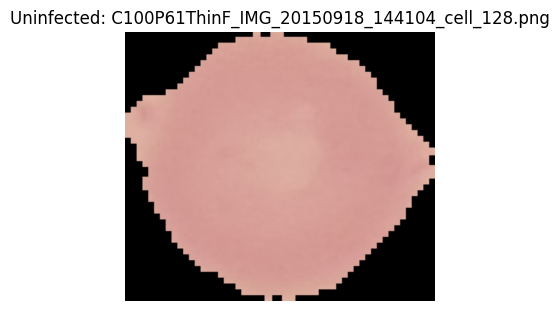

In [ ]:
para_path = f'{base}/Parasitized'
unin_path = f'{base}/Uninfected'
#para_path = f'{base}/POC Parasitized'
#unin_path = f'{base}/POC Uninfected'

files = sorted(os.listdir(unin_path))
print(f"Files found: {len(files)}")
print(f"First file: {files[0]}")

img = Image.open(f'{unin_path}/{files[0]}')
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f'Uninfected: {files[0]}')
plt.axis('off')
plt.show()

## Logistic Regression Baseline
### Image Preprocessing
Each image is resized to 64×64, converted to RGB, and a background mask is computed by thresholding pixels with mean intensity > 20 (dark pixels = background). Pixel values are normalized to [0, 1]. A sample parasitized image is shown with its mask and background-removed version.

In [ ]:
def preprocess_image(img_path, target_size=(64, 64)):
    # 1. Load image
    img = np.array(Image.open(img_path).convert('RGB'))

    # 2. Resize to standard size
    img_resized = cv2.resize(img, target_size)

    # 3. Create background mask (black pixels = background)
    #    Background pixels have all channels < 20
    mask = img_resized.mean(axis=2) > 20  # True = cell, False = background

    # 4. Normalize pixel values to 0-1
    img_normalized = img_resized / 255.0

    return img_normalized, mask

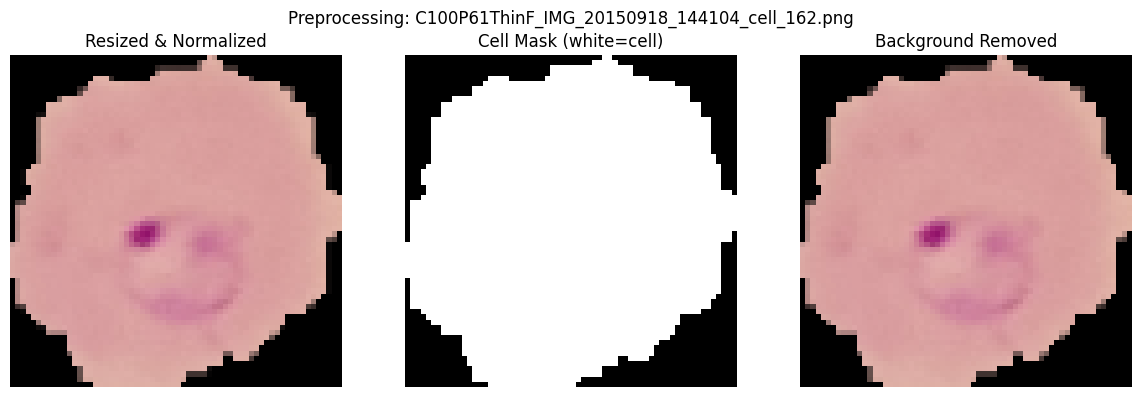

Image shape     : (64, 64, 3)
Cell pixels     : 3103
Background pixels: 993


In [ ]:
para_files = sorted(os.listdir(para_path))
unin_files = sorted(os.listdir(unin_path))

# Test on first parasitized image
img_norm, mask = preprocess_image(f'{para_path}/{para_files[0]}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
axes[0].imshow((img_norm))
axes[0].set_title('Resized & Normalized')
axes[0].axis('off')

# Mask
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Cell Mask (white=cell)')
axes[1].axis('off')

# Masked image (background removed)
img_masked = img_norm.copy()
img_masked[~mask] = 0
axes[2].imshow(img_masked)
axes[2].set_title('Background Removed')
axes[2].axis('off')

plt.suptitle(f'Preprocessing: {para_files[0]}', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Image shape     : {img_norm.shape}")
print(f"Cell pixels     : {mask.sum()}")
print(f"Background pixels: {(~mask).sum()}")

### Load All Images
Load every `.png` from both class folders, applying preprocessing and storing images, masks, labels, and filenames. Labels: 1 = Parasitized, 0 = Uninfected.

In [ ]:
from tqdm.notebook import tqdm

def load_all_images(folder_path, label, target_size=(64, 64)):
    images, masks, labels, filenames = [], [], [], []
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.png')])

    for fname in tqdm(files, desc=f"Loading {'Parasitized' if label == 1 else 'Uninfected'}", unit="img"):
        fpath = os.path.join(folder_path, fname)
        img_norm, mask = preprocess_image(fpath, target_size)
        images.append(img_norm)
        masks.append(mask)
        labels.append(label)
        filenames.append(fname)

    return images, masks, labels, filenames

# Load both classes
para_imgs, para_masks, para_labels, para_fnames = load_all_images(para_path, label=1)
unin_imgs, unin_masks, unin_labels, unin_fnames = load_all_images(unin_path, label=0)

print(f"Parasitized loaded : {len(para_imgs)}")
print(f"Uninfected loaded  : {len(unin_imgs)}")
print(f"Image shape        : {para_imgs[0].shape}")

Loading Parasitized:   0%|          | 0/13782 [00:00<?, ?img/s]

KeyboardInterrupt: 

### Feature Extraction
Five hand-crafted color/saturation features are extracted per image, computed only over non-background (cell) pixels:
- `magenta_ratio` — fraction of pixels matching parasite stain color
- `high_sat_ratio` — fraction of highly saturated pixels (HSV saturation > 100)
- `sat_variance` — spatial unevenness in saturation across the cell
- `sat_max` — peak saturation, capturing the brightest parasite spot
- `g_std` — green channel std, measuring contrast between cell pink and parasite magenta

In [ ]:
#extract features. We have 5 features (Jason, I added some diff from our proposal. Green is the complimentary color to magenta so is a good metric too)

def extract_features(img_norm, mask):
    r = img_norm[:,:,0]
    g = img_norm[:,:,1]
    b = img_norm[:,:,2]

    img_uint8 = (img_norm * 255).astype(np.uint8)
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    s = hsv[:,:,1]

    r_cell = r[mask]
    g_cell = g[mask]
    b_cell = b[mask]
    s_cell = s[mask]

    # 1. Magenta ratio — directly targets parasite stain color
    magenta_mask = (r_cell > 0.5) & (g_cell < 0.35) & (b_cell > 0.3)
    magenta_ratio = magenta_mask.sum() / mask.sum()

    # 2. High saturation ratio — magenta spots are highly saturated
    high_sat_ratio = (s_cell > 100).sum() / mask.sum()

    # 3. Saturation variance — parasitized = uneven (pink + magenta spikes)
    sat_variance = s_cell.var()

    # 4. Max saturation — peak intensity of brightest parasite spot
    sat_max = s_cell.max()

    # 5. Green std — high contrast between pink cell and magenta spots
    g_std = g_cell.std()

    return [magenta_ratio, high_sat_ratio, sat_variance, sat_max, g_std]

feature_names = ['magenta_ratio', 'high_sat_ratio', 'sat_variance',
                 'sat_max', 'g_std']

### Build Feature Matrix
Iterate over all images to produce feature matrix `X` (shape: n_images × 5) and label vector `y`. Each row is one image; each column is one feature.

In [ ]:

# Build feature matrix
# A "feature matrix" is just a table where:
#   - Each ROW    = one image
#   - Each COLUMN = one feature (magenta_ratio, g_std, etc.)
#   - y           = the answer key (0=uninfected, 1=parasitized)
#
# Example of what X looks like:
#
#   [magenta_ratio, high_sat_ratio, sat_variance, ..., g_std]
#   [0.02,          0.01,           12.3,         ..., 0.04]  ← uninfected image
#   [0.15,          0.12,           89.1,         ..., 0.11]  ← parasitized image
#   ...
#
# Logistic regression reads this table and learns:
# "when these numbers are high/low → parasitized or not"
# ============================================================

X, y = [], []

for img, mask, label in zip(para_imgs, para_masks, para_labels):
    X.append(extract_features(img, mask))
    y.append(label)

for img, mask, label in zip(unin_imgs, unin_masks, unin_labels):
    X.append(extract_features(img, mask))
    y.append(label)

X = np.array(X)   # shape: (200, 5)
y = np.array(y)   # shape: (200,)

print(f"Feature matrix shape : {X.shape}")       # expect (200, 5)
print(f"Label distribution   : {np.bincount(y)}") # expect [100, 100]

### Save Features to CSV
Export the feature matrix and labels to a CSV file on Drive for reuse without reprocessing images.

In [ ]:

df = pd.DataFrame(X, columns=feature_names)
df['label'] = y

# save_path = '/content/drive/Shareddrives/RAD260/BMI260/Final project/all_images_features.csv'
save_path = '/content/drive/Shareddrives/RAD260/BMI260/Final project/POC_features.csv'
df.to_csv(save_path, index=False)

print(f"Saved shape : {df.shape}")        # expect (200, 6)
print(f"Columns     : {list(df.columns)}")
print(df.head())

### Save Features to CSV
Export the feature matrix and labels to a CSV file on Drive for reuse without reprocessing images.

In [ ]:
# VALIDATE FEATURES
df['class'] = df['label'].map({0: 'Uninfected', 1: 'Parasitized'})

# --- Comparison table ---
comparison = df.groupby('class').mean()[feature_names].T
comparison.columns = ['Uninfected', 'Parasitized']
comparison['Difference'] = comparison['Parasitized'] - comparison['Uninfected']
comparison['Signal'] = comparison['Difference'].apply(
    lambda x: '⬆ HIGHER in parasitized' if x > 0 else '⬇ LOWER in parasitized'
)
print(comparison.round(4).to_string())

# --- Box plots ---
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, feat in enumerate(feature_names):
    df.boxplot(column=feat, by='class', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

# --- Correlation heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df[df['label']==0][feature_names].corr(),
            annot=True, fmt='.2f', cmap='Blues',
            center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Uninfected — Feature Correlations', fontsize=13)

sns.heatmap(df[df['label']==1][feature_names].corr(),
            annot=True, fmt='.2f', cmap='Reds',
            center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Parasitized — Feature Correlations', fontsize=13)

plt.suptitle('Feature Correlation by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Load Feature CSV (Partner Entry Point)
Reload the saved feature CSV — no image processing needed. This cell is the entry point if picking up from saved features rather than rerunning extraction.

In [ ]:
# Load features
# save_path = '/content/drive/Shareddrives/RAD260/BMI260/Final project/all_images_features.csv'
save_path = '/content/drive/Shareddrives/RAD260/BMI260/Final project/POC_features.csv'

df = pd.read_csv(save_path)

# Separate features (X) and labels (y)
feature_names = ['magenta_ratio', 'high_sat_ratio', 'sat_variance',
                 'sat_max', 'g_std']

X = df[feature_names].values   # shape: (200, 5)
y = df['label'].values         # shape: (200,)

# Sanity check
print(f"Feature matrix shape : {X.shape}")        # expect (200, 5)
print(f"Label distribution   : {np.bincount(y)}") # expect [100, 100]
print(f"Columns              : {list(df.columns)}")
print(df.head())

In [ ]:
print(df.columns.tolist())
print(df.head())

### Train/Test Split
80/20 stratified split. `stratify=y` ensures both classes remain balanced in train and test sets. `random_state=42` makes the split reproducible.

In [ ]:
# 80% train / 20% test, stratified so both classes are balanced
# in each split (prevents one class from being under-represented)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,    # fixed seed → reproducible split
    stratify=y          # keeps 50/50 class ratio in both sets
)

print(f"Train set : {X_train.shape}  labels: {np.bincount(y_train)}")
print(f"Test  set : {X_test.shape}  labels: {np.bincount(y_test)}")

### Feature Scaling
Standardize features to mean 0, std 1 using `StandardScaler`. Fit only on train set, then apply to both — fitting on test would leak information. Necessary because features have very different raw ranges (e.g. `sat_max` spans 0–255 while `magenta_ratio` spans 0–0.1).

Our 5 features have very different ranges:
  magenta_ratio  ~ 0–0.1
  sat_variance   ~ 0–300
  sat_max        ~ 0–255
Logistic regression's coefficients get dominated by the
large-scale features unless we standardize (mean 0, std 1).

IMPORTANT: fit on train only, then transform both.
Fitting on test would leak test info into the model.

In [ ]:
# STEP 7: SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("After scaling (train set):")
print(f"  mean per feature : {X_train_scaled.mean(axis=0).round(3)}")
print(f"  std  per feature : {X_train_scaled.std(axis=0).round(3)}")

### Train Logistic Regression
Logistic regression learns a weight per feature, combining them into a probability of "parasitized." Learned coefficients are printed — larger absolute value = more influence on the prediction.

In [ ]:
# STEP 8: TRAIN LOGISTIC REGRESSION
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Look at what the model learned
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Learned coefficients (larger |value| = more influence):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_[0]:.3f}")

### Evaluate Logistic Regression
Predict on the held-out test set. Reports: accuracy, precision/recall/F1 per class, confusion matrix, and predicted probability histograms by true class. The probability histogram shows how confidently the model separates the two classes.

Predict on the held-out test set, then report:
  - overall accuracy
  - confusion matrix (TP/FP/TN/FN)
  - per-class precision/recall/F1

In [ ]:
# STEP 9: EVALUATE & VISUALIZE
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]   # P(parasitized)

# --- Accuracy ---
accuracy = (y_pred == y_test).mean()
print(f"Test accuracy: {accuracy:.3f}  ({(y_pred == y_test).sum()}/{len(y_test)})")
print()

# --- Classification report ---
print("Classification report:")
print(classification_report(y_test, y_pred,
                            target_names=['Uninfected', 'Parasitized']))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'],
            ax=axes[0], cbar=False)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (accuracy = {accuracy:.2%})')

# Plot 2: predicted probabilities by true class
axes[1].hist(y_prob[y_test == 0], bins=15, alpha=0.6,
             label='Uninfected (true)', color='steelblue')
axes[1].hist(y_prob[y_test == 1], bins=15, alpha=0.6,
             label='Parasitized (true)', color='crimson')
axes[1].axvline(0.5, color='black', linestyle='--', label='decision threshold')
axes[1].set_xlabel('Predicted probability of parasitized')
axes[1].set_ylabel('Count')
axes[1].set_title('Model confidence by true class')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# check the outputs:

# Sanity: are train and test actually disjoint and balanced?
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train labels: {np.bincount(y_train)}")  # expect [80, 80]
print(f"Test labels:  {np.bincount(y_test)}")   # expect [20, 20]

# Sanity: did scaling actually do something?
print(f"\nRaw X_train means: {X_train.mean(axis=0).round(2)}")
print(f"Scaled means:      {X_train_scaled.mean(axis=0).round(2)}")  # should be ~0

# **DINOv2 Deep Learning Model**

### Data Splits
The full dataset (all `.png` files from both class folders) is collected into a single list of `(path, label)` tuples — 1 for parasitized, 0 for uninfected. A two-step stratified split produces a 70/15/15 train/val/test division.

The first split carves out 15% as the test set. The second split takes the remaining 85% and pulls out ~15% of the original total as validation (0.176 × 0.85 ≈ 0.15). `stratify=all_labels` is used at both steps to ensure the 50/50 class balance is preserved in every split — without this, random chance could leave one class underrepresented in the small val/test sets.

Unlike the logistic regression baseline which only used train/test, DINOv2 needs a **validation set** during training for two purposes: (1) learning rate scheduling — the scheduler watches val loss to decide when to reduce lr, and (2) early stopping — training halts when val recall stops improving, preventing overfitting.

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

# Gather all file paths and labels
para_files = [(os.path.join(para_path, f), 1)
              for f in sorted(os.listdir(para_path))
              if f.endswith('.png')]
unin_files = [(os.path.join(unin_path, f), 0)
              for f in sorted(os.listdir(unin_path))
              if f.endswith('.png')]

all_files  = para_files + unin_files
all_paths  = [f[0] for f in all_files]
all_labels = [f[1] for f in all_files]

# 70% train / 15% val / 15% test, stratified
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.15, random_state=42, stratify=all_labels
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.176, random_state=42, stratify=train_val_labels
)

print(f"Train      : {len(train_paths)} images  ({sum(train_labels)} para, {train_labels.count(0)} unin)")
print(f"Validation : {len(val_paths)} images  ({sum(val_labels)} para, {val_labels.count(0)} unin)")
print(f"Test       : {len(test_paths)} images  ({sum(test_labels)} para, {test_labels.count(0)} unin)")

Train      : 19354 images  (9652 para, 9702 unin)
Validation : 4134 images  (2062 para, 2072 unin)
Test       : 4146 images  (2068 para, 2078 unin)


### Device Setup
Detects whether a CUDA-capable GPU is available and sets `device` accordingly. All tensors (images, labels, model weights) will be moved to this device during training.

**This cell should print `cuda` before you proceed.** If it prints `cpu`, your runtime does not have a GPU attached and DINOv2 training will be extremely slow — go back and verify your accelerator is configured correctly.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Data Augmentation & Transforms
Two separate transform pipelines are defined — one for training, one for val/test.

**Training transforms** apply random augmentations to artificially increase dataset diversity:
- `RandomHorizontalFlip` and `RandomVerticalFlip` — cell images have no meaningful orientation, so flipping is always valid and doubles/quadruples effective data variety
- `ColorJitter(brightness=0.2, contrast=0.2)` — simulates variability in staining intensity and microscope illumination across different slide preparations

**Val/test transforms** apply only deterministic steps (resize + normalize) so evaluation is consistent and reproducible — augmentation during eval would introduce randomness into metrics.

All images are resized to **224×224** regardless of original size. This is not arbitrary: DINOv2 uses a Vision Transformer with patch size 14, meaning it divides the image into a grid of 14×14 pixel patches. The input dimensions must be exact multiples of 14, and 224 = 16 × 14 is the standard choice inherited from ImageNet pretraining.

**ImageNet normalization** (`mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]`) is applied last. DINOv2 was pretrained on ImageNet with these statistics, so inputs need to be in the same distribution the backbone expects — without this, the pretrained features would be partially invalidated.

In [ ]:
# DINOv2 patch size is 14, so input dims must be multiples of 14
# 224 = 16 * 14. ImageNet normalization stats apply.
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Dataset & DataLoaders
A lightweight inline dataset class `_DS` is defined inside `make_dataset()`. It implements the two methods PyTorch requires from any dataset: `__len__` (returns total image count) and `__getitem__` (opens one image by index, applies the transform, and returns it with its label). Images are loaded lazily — only when a batch requests them — rather than all at once into memory.

Three DataLoaders are created from this:
- `train_loader` — `shuffle=True` so the model sees images in a different order each epoch, preventing it from memorizing batch sequences
- `val_loader` and `test_loader` — `shuffle=False` so evaluation order is deterministic

`batch_size=64` means 64 images are processed together in each forward pass. `num_workers=4` spawns 4 background processes to load and preprocess the next batch while the GPU is training on the current one — this keeps the GPU fed without idle waiting. `pin_memory=True` allocates batches in page-locked RAM, which allows faster CPU→GPU transfer.

In [ ]:
from torch.utils.data import DataLoader

def make_dataset(paths, labels, transform):
    """Returns an object that DataLoader can iterate over."""
    class _DS:
        def __len__(self): return len(paths)
        def __getitem__(self, i):
            img = Image.open(paths[i]).convert('RGB')
            return transform(img), labels[i]
    return _DS()

train_dataset = make_dataset(train_paths, train_labels, train_transforms)
val_dataset   = make_dataset(val_paths,   val_labels,   val_test_transforms)
test_dataset  = make_dataset(test_paths,  test_labels,  val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

Train batches      : 303
Validation batches : 65
Test batches       : 65


### Model Architecture
The model is a two-component sequential pipeline:

**Component 1 — DINOv2 backbone (`dinov2_vits14`):**
Loaded from `facebookresearch/dinov2` via `torch.hub`. This is a Vision Transformer (ViT) pretrained using self-supervised learning on a large curated dataset — it has never seen malaria cells, but it has learned rich general-purpose visual features (edges, textures, shapes, color relationships). The `vits14` variant is the small version: 12 transformer blocks, 6 attention heads, 384-dimensional output. When an image is passed through it, the backbone returns a single 384-dimensional CLS token vector that summarizes the whole image.

All backbone parameters are frozen with `p.requires_grad = False` — their weights will not be updated during Stage 1 training. The backbone is being used purely as a feature extractor.

**Component 2 — Classifier head:**
A small MLP that takes the 384-dim backbone output and maps it to a single probability:
- `Dropout(0.3)` — randomly zeros 30% of inputs during training to reduce overfitting
- `Linear(384 → 128)` — compresses the feature vector
- `ReLU` — introduces non-linearity
- `Linear(128 → 1)` — collapses to a single logit
- `Sigmoid` — squashes output to [0, 1], interpreted as P(parasitized)

**Loss function:** `BCELoss` (binary cross-entropy) — the standard loss for binary classification with sigmoid output. It penalizes confident wrong predictions more heavily than uncertain ones.

The trainable parameter count printed at the end confirms that in Stage 1, only the ~50K head parameters are being trained out of the full ~21M — about 0.2% of the model.

In [ ]:
import torch
import torch.nn as nn

# dinov2_vits14: small ViT, 384-dim CLS embedding
# Alternatives: dinov2_vitb14 (768-dim), dinov2_vitl14 (1024-dim)
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

for p in dino.parameters():
    p.requires_grad = False

classifier_head = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(384, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

# nn.Sequential: model[0] = DINOv2 backbone, model[1] = classifier head
model = nn.Sequential(dino, classifier_head).to(device)
criterion = nn.BCELoss()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 437MB/s]


Trainable params: 49,409 / 22,105,985 (0.22%)


### Training Loop
The `train_model()` function runs the full train/validate cycle for a given number of epochs.

**Each epoch has two phases:**

*Train phase* (`model.train()`): iterates over all batches in `train_loader`. For each batch:
1. Move images and labels to GPU
2. Zero out gradients from the previous step (`optimizer.zero_grad()`) — PyTorch accumulates gradients by default, so this must be explicitly reset
3. Forward pass: images flow through backbone → head → sigmoid → predicted probabilities
4. Compute BCE loss between predictions and true labels
5. Backpropagate (`loss.backward()`) — computes gradients of loss w.r.t. all trainable parameters
6. Update weights (`optimizer.step()`)

*Validation phase* (`model.eval()`): iterates over `val_loader` with `torch.no_grad()` (disables gradient tracking entirely for speed and memory efficiency). Computes loss, accuracy, AUC-ROC, and recall on the validation set. No weight updates happen here.

**Early stopping:** The model saves a checkpoint whenever validation recall improves (AUC is the tiebreaker for equal recall). A `patience_counter` tracks how many consecutive epochs have passed without improvement. If it reaches `patience=7`, training halts early and the best checkpoint is reloaded. This prevents the model from overfitting by training too long.

**Why recall as the primary metric?** In a medical screening context, a false negative (predicting uninfected when the cell is actually parasitized) is more dangerous than a false positive. Optimizing for recall directly targets this — it pushes the model to miss as few parasitized cells as possible.

**Learning rate scheduling:** `ReduceLROnPlateau` watches val loss and halves the learning rate (`factor=0.5`) if it hasn't improved for 3 epochs. This allows aggressive initial learning followed by finer adjustments as training matures.

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=10, stage_name='model', patience=7):

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_recall = 0.0
    best_val_auc    = 0.0
    patience_counter = 0

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        train_loss, train_correct = 0, 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (outputs > 0.5).float()
            train_correct += (preds == labels).sum().item()

        # --- VAL ---
        model.eval()
        val_loss, val_correct = 0, 0
        val_probs_list, val_labels_list = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().to(device)
                outputs = model(images).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = (outputs > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_probs_list.extend(outputs.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg   = val_loss   / len(val_loader)
        train_acc      = train_correct / len(train_loader.dataset)
        val_acc        = val_correct   / len(val_loader.dataset)

        train_losses.append(train_loss_avg)
        val_losses.append(val_loss_avg)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        val_preds_binary = (np.array(val_probs_list) > 0.5).astype(int)
        val_auc    = roc_auc_score(val_labels_list, val_probs_list)
        val_recall = recall_score(val_labels_list, val_preds_binary)

        if scheduler is not None:
            scheduler.step(val_loss_avg)

        # Early stop on recall, tiebreak on AUC
        improved = (val_recall > best_val_recall or
                    (val_recall == best_val_recall and val_auc > best_val_auc))
        if improved:
            best_val_recall = val_recall
            best_val_auc    = val_auc
            torch.save(model.state_dict(), f'best_{stage_name}.pth')
            patience_counter = 0
            saved = f"✓ best saved (recall={val_recall:.4f}, auc={val_auc:.4f})"
        else:
            patience_counter += 1
            saved = f"patience {patience_counter}/{patience}"

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.4f} | "
              f"Val Recall: {val_recall:.4f} | Val AUC: {val_auc:.4f} | {saved}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(f'best_{stage_name}.pth'))
    return train_losses, val_losses, train_accs, val_accs

### Evaluation Function
`evaluate_model()` runs inference on the test set and produces a comprehensive report.

**Classification report:** Per-class precision, recall, and F1 for both Uninfected and Parasitized at the default 0.5 threshold.

**AUC-ROC:** Area under the ROC curve — measures how well the model ranks parasitized images above uninfected ones across all possible thresholds. A value of 1.0 is perfect; 0.5 is random. Unlike accuracy, AUC is threshold-independent, making it a more robust summary of model quality.

**Confusion matrix:** Shows the raw counts of true positives, false positives, true negatives, and false negatives. Lets you see exactly where the model is making errors.

**Threshold sweep (0.1–0.9):** The sigmoid output is a continuous probability, and 0.5 is just the default decision boundary. This sweep shows what happens to recall, precision, and F1 as you move the threshold. Lowering the threshold (e.g. to 0.3) catches more parasitized cells (higher recall) but at the cost of more false alarms (lower precision). The sweep flags thresholds where recall ≥ 99% — relevant if this were deployed in a clinical pre-screening setting where missing infections is unacceptable.

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay,
                              precision_score, f1_score)

# define the process of evaluating the model. Produce the test metrics
def evaluate_model(model, test_loader, stage_name):
    model.eval()
    all_preds, all_labels_list, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images).squeeze()
            probs = outputs.cpu().numpy()
            preds = (outputs > 0.5).float().cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels_list.extend(labels.numpy())

    print(f"\n{'=' * 60}\n{stage_name} TEST RESULTS\n{'=' * 60}")
    print(classification_report(all_labels_list, all_preds,
                                target_names=['Uninfected', 'Parasitized']))
    auc = roc_auc_score(all_labels_list, all_probs)
    print(f"AUC-ROC: {auc:.4f}")

    cm = confusion_matrix(all_labels_list, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Uninfected', 'Parasitized'])
    disp.plot(cmap='Blues')
    plt.title(f'{stage_name} — Confusion Matrix')
    plt.show()

    print(f"\nThreshold Analysis")
    print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1':<8} {'Flag'}")
    print("-" * 55)
    for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        preds_t = (np.array(all_probs) > t).astype(int)
        rec = recall_score(all_labels_list, preds_t, zero_division=0)
        pre = precision_score(all_labels_list, preds_t, zero_division=0)
        f1  = f1_score(all_labels_list, preds_t, zero_division=0)
        flag = '← >99% recall' if rec >= 0.99 else ''
        print(f"{t:<12.1f} {rec:<10.4f} {pre:<12.4f} {f1:<8.4f} {flag}")

    return all_labels_list, all_probs

### Stage 1: Train Frozen DINOv2
Only the classifier head (`model[1]`) is trained. The DINOv2 backbone (`model[0]`) is fully frozen — its weights don't move.

**Optimizer:** Adam with `lr=1e-3`. A relatively high learning rate is appropriate here because we're only training the small head from scratch — it needs to move quickly to fit the backbone's output distribution.

**Scheduler:** `ReduceLROnPlateau` on val loss with patience=3, factor=0.5.

**Why do Stage 1 at all before fine-tuning?** If you unfreeze the backbone immediately with a randomly initialized head, the large gradients from the untrained head flow back into the pretrained backbone and destabilize its weights (sometimes called "catastrophic forgetting"). Training the head first until it converges gives it a sensible initialization before the backbone is touched.

In [ ]:
# TRAIN FROZEN DINO v2

# save_dir persists to Drive so checkpoints survive session resets
save_dir = '/content/drive/Shareddrives/RAD260/BMI260/Final project/checkpoints'
os.makedirs(save_dir, exist_ok=True)
s1_ckpt = f'{save_dir}/dinov2_stage1_balanced.pth'

if os.path.exists(s1_ckpt):
# Checkpoint found — skip training entirely and reload saved weights

    print("Stage 1 checkpoint found — loading instead of retraining")
    model.load_state_dict(torch.load(s1_ckpt))
    model.eval()
    s1_train_losses, s1_val_losses, s1_train_accs, s1_val_accs = [], [], [], []
else:
# No checkpoint found — train from scratch
    print("STAGE 1: Training frozen DINOv2 + classifier head")
    print("=" * 60)
    optimizer_s1 = torch.optim.Adam(model[1].parameters(), lr=1e-3)
    scheduler_s1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s1, mode='min', patience=3, factor=0.5
    )
    s1_train_losses, s1_val_losses, s1_train_accs, s1_val_accs = train_model(
        model, train_loader, val_loader,
        criterion, optimizer_s1, scheduler_s1,
        epochs=15, stage_name='stage1_dino'
    )

    # Save to Drive immediately after training completes
    torch.save(model.state_dict(), s1_ckpt)
    print(f"✅ Stage 1 saved to {s1_ckpt}")

STAGE 1: Training frozen DINOv2 + classifier head
Epoch 01/15 | Train Loss: 0.1466 | Train Acc: 0.9471 | Val Loss: 0.1100 | Val Acc: 0.9615 | Val Recall: 0.9699 | Val AUC: 0.9925 | ✓ best saved (recall=0.9699, auc=0.9925)
Epoch 02/15 | Train Loss: 0.1247 | Train Acc: 0.9564 | Val Loss: 0.1037 | Val Acc: 0.9642 | Val Recall: 0.9612 | Val AUC: 0.9934 | patience 1/7
Epoch 03/15 | Train Loss: 0.1142 | Train Acc: 0.9590 | Val Loss: 0.1066 | Val Acc: 0.9642 | Val Recall: 0.9777 | Val AUC: 0.9941 | ✓ best saved (recall=0.9777, auc=0.9941)
Epoch 04/15 | Train Loss: 0.1120 | Train Acc: 0.9601 | Val Loss: 0.0975 | Val Acc: 0.9637 | Val Recall: 0.9612 | Val AUC: 0.9942 | patience 1/7
Epoch 05/15 | Train Loss: 0.1109 | Train Acc: 0.9598 | Val Loss: 0.1010 | Val Acc: 0.9627 | Val Recall: 0.9728 | Val AUC: 0.9940 | patience 2/7
Epoch 06/15 | Train Loss: 0.1070 | Train Acc: 0.9619 | Val Loss: 0.0980 | Val Acc: 0.9623 | Val Recall: 0.9554 | Val AUC: 0.9943 | patience 3/7
Epoch 07/15 | Train Loss: 0.10


STAGE 1 — Frozen DINOv2 TEST RESULTS
              precision    recall  f1-score   support

  Uninfected       0.97      0.95      0.96      2078
 Parasitized       0.95      0.97      0.96      2068

    accuracy                           0.96      4146
   macro avg       0.96      0.96      0.96      4146
weighted avg       0.96      0.96      0.96      4146

AUC-ROC: 0.9924


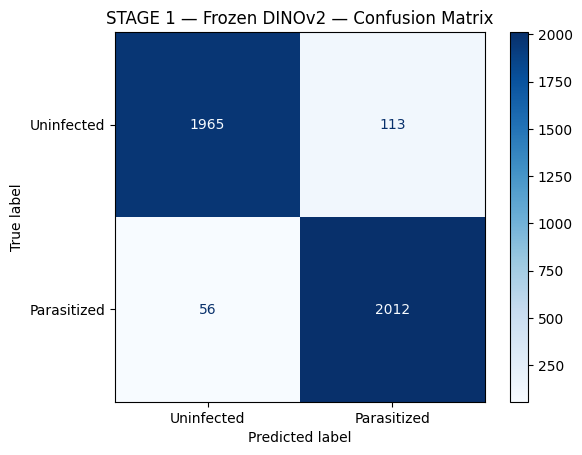


Threshold Analysis
Threshold    Recall     Precision    F1       Flag
-------------------------------------------------------
0.1          0.9947     0.8147       0.8957   ← >99% recall
0.2          0.9879     0.8764       0.9288   
0.3          0.9840     0.9113       0.9463   
0.4          0.9787     0.9293       0.9534   
0.5          0.9729     0.9468       0.9597   
0.6          0.9662     0.9569       0.9615   
0.7          0.9565     0.9611       0.9588   
0.8          0.9405     0.9710       0.9555   
0.9          0.9101     0.9864       0.9467   


In [ ]:
# EVALUATION

s1_labels, s1_probs = evaluate_model(model, test_loader, "STAGE 1 — Frozen DINOv2")

### Stage 2: Unfreeze & Fine-tune DINOv2

Unfreezes the last 2 of 12 transformer blocks and the final layer norm, then fine-tunes with a small learning rate. Earlier blocks stay frozen as they encode general low-level features that transfer well without adaptation.

The unfreeze step runs regardless of whether weights are loaded or trained — `requires_grad` must be set correctly in both cases.

**If a checkpoint exists on Drive:** weights are loaded and training is skipped entirely.

**If no checkpoint:** fine-tunes for up to 30 epochs (more than Stage 1's 15, since the smaller lr means slower convergence) with Adam at `lr=1e-5`. ViTs are sensitive to large learning rates during fine-tuning — too high and pretrained weights get overwritten. Saves to Drive on completion.

In [ ]:
# STAGE 2 CHECKPOINT PATH
s2_ckpt = f'{save_dir}/dinov2_stage2_balanced.pth'

# Unfreeze runs regardless of load vs train — requires_grad must be
# set correctly even when loading weights
backbone = model[0]
head     = model[1]

for p in head.parameters():
    p.requires_grad = True
for p in backbone.norm.parameters():
    p.requires_grad = True

# Only last 2 of 12 blocks — earlier layers learn general features
# that transfer well without adaptation
for i, block in enumerate(backbone.blocks):
    for p in block.parameters():
        p.requires_grad = (i >= len(backbone.blocks) - 2)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

if os.path.exists(s2_ckpt):
    print("Stage 2 checkpoint found — loading instead of retraining")
    model.load_state_dict(torch.load(s2_ckpt))
    model.eval()
    s2_train_losses, s2_val_losses, s2_train_accs, s2_val_accs = [], [], [], []

else:
    print("STAGE 2: Fine-tuning unfrozen DINOv2")
    print("=" * 60)

    # lr=1e-5 — ViTs are sensitive to large LRs during fine-tuning
    optimizer_s2 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
    )
    scheduler_s2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s2, mode='min', patience=3, factor=0.5
    )

    # 30 epochs vs 15 — fine-tuning progresses more slowly at smaller lr
    s2_train_losses, s2_val_losses, s2_train_accs, s2_val_accs = train_model(
        model, train_loader, val_loader,
        criterion, optimizer_s2, scheduler_s2,
        epochs=30, stage_name='stage2_dino'
    )

    torch.save(model.state_dict(), s2_ckpt)
    print(f"✅ Stage 2 saved to {s2_ckpt}")

### **[OLD]** Unfreeze Last 2 Transformer Blocks
Prepares the model for Stage 2 by selectively unfreezing parts of the backbone.

The DINOv2 `vits14` backbone has 12 transformer blocks (`backbone.blocks`). Only the **last 2** are unfrozen (`i >= unfreeze_from` where `unfreeze_from = 10`). The final layer norm (`backbone.norm`) is also unfrozen. Everything else — the patch embedding, positional embeddings, and first 10 blocks — stays frozen.

**Why only the last 2 blocks?** The earlier layers of a ViT learn low-level general features (edges, textures) that transfer well to any visual domain. The later layers learn more task-specific, high-level representations. By unfreezing only the tail, we allow the model to adapt its high-level features to malaria cell morphology while preserving the general visual foundation — and we dramatically reduce the risk of overfitting on a dataset that, while large for this project, is still small relative to ImageNet.

The updated trainable parameter count printed here will be significantly higher than Stage 1 — roughly 15-20% of total parameters depending on block size.

In [ ]:
# backbone = model[0]
# head     = model[1]
# n_blocks = len(backbone.blocks)
# unfreeze_from = n_blocks - 2   # last 2 of 12 blocks for vits14

# # Head: always trainable
# for p in head.parameters():
#     p.requires_grad = True

# # Final layernorm: trainable
# for p in backbone.norm.parameters():
#     p.requires_grad = True

# # Transformer blocks: only last 2 trainable
# for i, block in enumerate(backbone.blocks):
#     for p in block.parameters():
#         p.requires_grad = (i >= unfreeze_from)

# trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
# total     = sum(p.numel() for p in model.parameters())
# print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Trainable params: 3,600,641 / 22,105,985 (16.29%)


### **[OLD]** Stage 2: Fine-tune DINOv2
Fine-tunes the unfrozen blocks alongside the classifier head.

**Optimizer:** Adam with `lr=1e-5` — two orders of magnitude smaller than Stage 1. This is critical: Vision Transformers are much more sensitive to learning rate during fine-tuning than CNNs. A rate of 1e-3 here would overwrite the pretrained backbone weights too aggressively. The small lr allows the backbone to adapt gently to malaria cell features without forgetting its pretrained representations.

**Epochs:** Up to 30, with the same early stopping logic (patience=7 on val recall). Stage 2 is given more epochs than Stage 1 because fine-tuning progresses more slowly due to the small learning rate.

Best checkpoint saved to `best_stage2_dino.pth` and reloaded at the end.

In [ ]:
# # FINE TUNE

# # ViTs are LR-sensitive — 1e-5, much smaller than CNN fine-tuning
# optimizer_s2 = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=1e-5
# )
# scheduler_s2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer_s2, mode='min', patience=3, factor=0.5
# )

# print("STAGE 2: Fine-tuning unfrozen DINOv2")
# print("=" * 60)
# s2_train_losses, s2_val_losses, s2_train_accs, s2_val_accs = train_model(
#     model, train_loader, val_loader,
#     criterion, optimizer_s2, scheduler_s2,
#     epochs=30, stage_name='stage2_dino'
# )

# torch.save(model.state_dict(), f'{save_dir}/dinov2_stage2_balanced.pth')

STAGE 2: Fine-tuning unfrozen DINOv2
Epoch 01/30 | Train Loss: 0.1031 | Train Acc: 0.9633 | Val Loss: 0.0856 | Val Acc: 0.9678 | Val Recall: 0.9641 | Val AUC: 0.9953 | ✓ best saved (recall=0.9641, auc=0.9953)
Epoch 02/30 | Train Loss: 0.0915 | Train Acc: 0.9665 | Val Loss: 0.0954 | Val Acc: 0.9647 | Val Recall: 0.9821 | Val AUC: 0.9957 | ✓ best saved (recall=0.9821, auc=0.9957)
Epoch 03/30 | Train Loss: 0.0798 | Train Acc: 0.9723 | Val Loss: 0.0831 | Val Acc: 0.9707 | Val Recall: 0.9714 | Val AUC: 0.9957 | patience 1/7
Epoch 04/30 | Train Loss: 0.0773 | Train Acc: 0.9714 | Val Loss: 0.0812 | Val Acc: 0.9707 | Val Recall: 0.9762 | Val AUC: 0.9959 | patience 2/7
Epoch 05/30 | Train Loss: 0.0703 | Train Acc: 0.9749 | Val Loss: 0.0773 | Val Acc: 0.9746 | Val Recall: 0.9699 | Val AUC: 0.9962 | patience 3/7
Epoch 06/30 | Train Loss: 0.0668 | Train Acc: 0.9749 | Val Loss: 0.0792 | Val Acc: 0.9729 | Val Recall: 0.9709 | Val AUC: 0.9964 | patience 4/7
Epoch 07/30 | Train Loss: 0.0644 | Train Ac


STAGE 2 — Fine-tuned DINOv2 TEST RESULTS
              precision    recall  f1-score   support

  Uninfected       0.98      0.95      0.96      2078
 Parasitized       0.95      0.98      0.96      2068

    accuracy                           0.96      4146
   macro avg       0.96      0.96      0.96      4146
weighted avg       0.96      0.96      0.96      4146

AUC-ROC: 0.9947


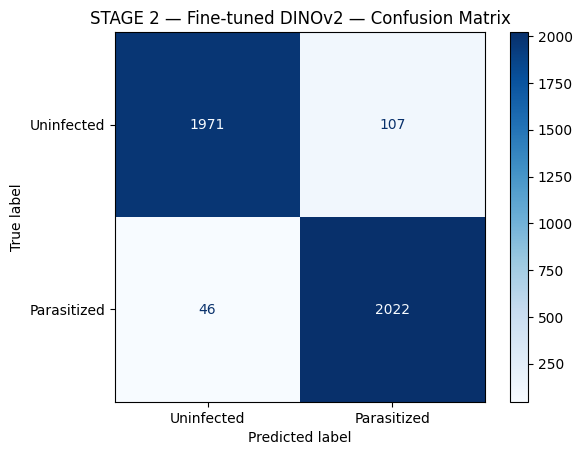


Threshold Analysis
Threshold    Recall     Precision    F1       Flag
-------------------------------------------------------
0.1          0.9942     0.8250       0.9018   ← >99% recall
0.2          0.9918     0.8724       0.9283   ← >99% recall
0.3          0.9874     0.9088       0.9465   
0.4          0.9816     0.9286       0.9544   
0.5          0.9778     0.9497       0.9635   
0.6          0.9720     0.9640       0.9680   
0.7          0.9642     0.9732       0.9687   
0.8          0.9502     0.9830       0.9663   
0.9          0.9338     0.9872       0.9597   


In [ ]:
# STAGE 2 EVALUATION

s2_labels, s2_probs = evaluate_model(model, test_loader, "STAGE 2 — Fine-tuned DINOv2")

### Summary: Stage 1 vs Stage 2 Comparison
Training curves plot loss and accuracy for both stages on the same axes, letting you visually compare how frozen vs. fine-tuned training progressed. Stage 1 curves (blue) typically show faster initial convergence; Stage 2 curves (red) show slower but continued improvement.

The final summary table compares four metrics side by side:
- **Accuracy** — overall fraction correct
- **AUC-ROC** — threshold-independent ranking quality
- **Recall** — fraction of parasitized cells correctly identified (the primary clinical metric)
- **Precision** — fraction of positive predictions that were actually parasitized

If fine-tuning worked, Stage 2 should show improvement on recall and AUC relative to Stage 1, confirming that adapting the backbone's representations to malaria cell morphology added real value beyond just training the classification head.

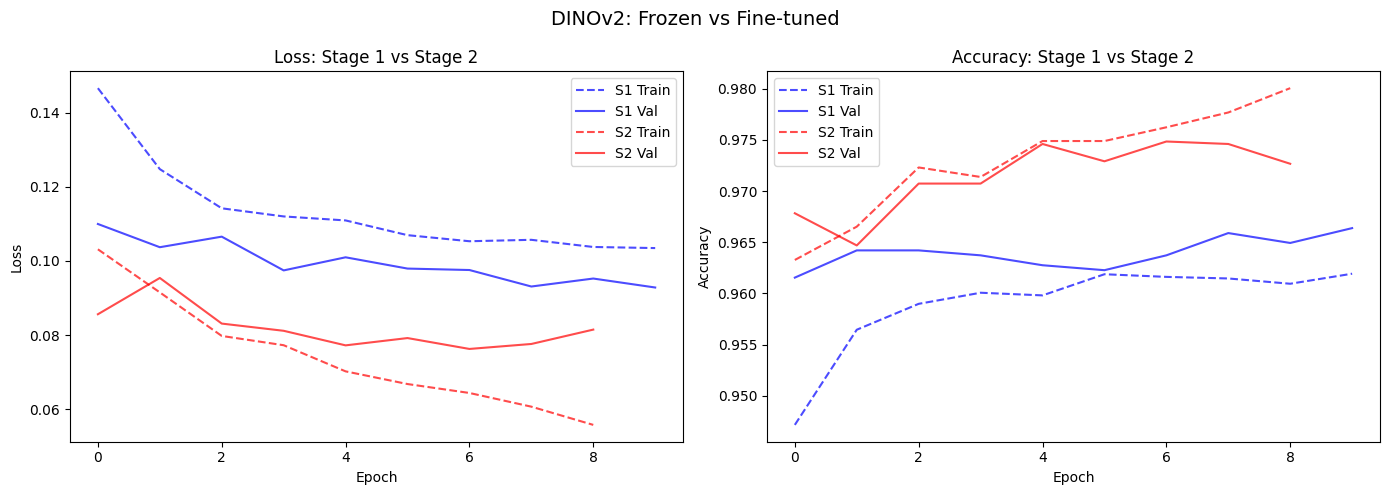


FINAL COMPARISON SUMMARY
Metric               Stage 1 (Frozen)     Stage 2 (Fine-tuned)
------------------------------------------------------------
Accuracy             0.9592               0.9631
AUC-ROC              0.9924               0.9947
Recall               0.9729               0.9778
Precision            0.9468               0.9497


In [ ]:
# SUMMARY BLOCK

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(s1_train_losses, 'b--', alpha=0.7, label='S1 Train')
axes[0].plot(s1_val_losses,   'b-',  alpha=0.7, label='S1 Val')
axes[0].plot(s2_train_losses, 'r--', alpha=0.7, label='S2 Train')
axes[0].plot(s2_val_losses,   'r-',  alpha=0.7, label='S2 Val')
axes[0].set_title('Loss: Stage 1 vs Stage 2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(s1_train_accs, 'b--', alpha=0.7, label='S1 Train')
axes[1].plot(s1_val_accs,   'b-',  alpha=0.7, label='S1 Val')
axes[1].plot(s2_train_accs, 'r--', alpha=0.7, label='S2 Train')
axes[1].plot(s2_val_accs,   'r-',  alpha=0.7, label='S2 Val')
axes[1].set_title('Accuracy: Stage 1 vs Stage 2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.suptitle('DINOv2: Frozen vs Fine-tuned', fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
from sklearn.metrics import accuracy_score
s1_acc = accuracy_score(s1_labels, (np.array(s1_probs) > 0.5).astype(int))
s2_acc = accuracy_score(s2_labels, (np.array(s2_probs) > 0.5).astype(int))
s1_auc = roc_auc_score(s1_labels, s1_probs)
s2_auc = roc_auc_score(s2_labels, s2_probs)
s1_rec = recall_score(s1_labels, (np.array(s1_probs) > 0.5).astype(int))
s2_rec = recall_score(s2_labels, (np.array(s2_probs) > 0.5).astype(int))
s1_pre = precision_score(s1_labels, (np.array(s1_probs) > 0.5).astype(int))
s2_pre = precision_score(s2_labels, (np.array(s2_probs) > 0.5).astype(int))

print("\nFINAL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Metric':<20} {'Stage 1 (Frozen)':<20} {'Stage 2 (Fine-tuned)'}")
print("-" * 60)
print(f"{'Accuracy':<20} {s1_acc:<20.4f} {s2_acc:.4f}")
print(f"{'AUC-ROC':<20} {s1_auc:<20.4f} {s2_auc:.4f}")
print(f"{'Recall':<20} {s1_rec:<20.4f} {s2_rec:.4f}")
print(f"{'Precision':<20} {s1_pre:<20.4f} {s2_pre:.4f}")

## Class Imbalance Simulation

### Motivation
The balanced 50/50 dataset used in initial training represents the least realistic clinical condition. In practice, malaria positivity rates among febrile patients range from approximately 5–40% (Belay et al., 2023; Onken et al., 2023; Duguma et al., 2024; Legesse et al., 2026). This section retrains the DINOv2 model across this prevalence range to evaluate whether high recall is maintained under more realistic screening conditions, and how precision degrades as parasitized cells become increasingly rare.

---

### Dataset Construction
To simulate each prevalence level, all uninfected cells are kept and parasitized cells are subsampled to hit the target rate. No new data is needed — the existing dataset is simply rebalanced. A fixed numpy seed ensures the subsampling is reproducible across runs.

Given a target prevalence `p` and `n_unin` uninfected cells, the required number of parasitized cells is derived as:

$$n_{para} = \frac{p \times n_{unin}}{1 - p}$$


In [ ]:
USER_SEED = 42

def create_imbalanced_dataset(para_paths, unin_paths, prevalence, seed=USER_SEED):
    np.random.seed(seed) # for repetition

    # use dataset construction given above ^
    n_unin = len(unin_paths)
    n_para = int((prevalence * n_unin) / (1 - prevalence))
    n_para = min(n_para, len(para_paths))

    para_sample = list(np.random.choice(para_paths, n_para, replace=False))

    all_paths  = para_sample + unin_paths
    all_labels = [1] * n_para + [0] * n_unin

    print(f"Prevalence {prevalence:.0%}: {n_para} para / {n_unin} unin "
          f"({n_para/(n_para+n_unin):.1%} actual)")

    return all_paths, all_labels

### Class Imbalance Simulation Loop

Iterates over five prevalence levels (5%, 10%, 20%, 40%, 50%) training a fresh DINOv2 model at each one to simulate realistic clinical screening conditions.

**Resume logic:** At the start, checks Drive for an existing results CSV. If found, completed prevalences are loaded and skipped — the loop picks up from where it left off. This means a session crash mid-loop doesn't require restarting from scratch.

**Per prevalence, the loop:**
1. Subsamples the dataset to the target prevalence using `create_imbalanced_dataset()`
2. Rebuilds train/val/test splits and DataLoaders
3. Reinitializes a fresh DINOv2 model — each prevalence gets a clean starting point
4. Runs Stage 1 (frozen backbone, head only, lr=1e-3, 15 epochs)
5. Unfreezes the last 2 transformer blocks and layer norm for Stage 2
6. Runs Stage 2 (fine-tuning, lr=1e-5, 30 epochs)
7. Saves the trained checkpoint to Drive (`dinov2_prevXX.pth`)
8. Evaluates on the test set and records recall, precision, AUC, and F1
9. Saves the results CSV to Drive immediately — not just at the end

The final `print` outside the loop displays the full results table across all prevalence levels.

In [ ]:
save_dir = '/content/drive/Shareddrives/RAD260/BMI260/Final project/checkpoints'
os.makedirs(save_dir, exist_ok=True)

results_path = f'{save_dir}/prevalence_results.csv'
prevalences = [0.05, 0.10, 0.20, 0.40, 0.50]

# if results CSV already exists, load it and skip completed prevalences
if os.path.exists(results_path):
    results = pd.read_csv(results_path).to_dict('records')
    completed = {r['prevalence'] for r in results}
    print(f"Resuming — already completed: {completed}")
else:
    results = []
    completed = set()

for prev in prevalences:

    ckpt_path = f'{save_dir}/dinov2_prev{int(prev*100):02d}.pth'
    if prev in completed and os.path.exists(ckpt_path):
      print(f"Skipping {prev:.0%} — checkpoint and results already exist")
      continue

    paths, labels = create_imbalanced_dataset(para_paths, unin_paths, prev)

    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        paths, labels, test_size=0.15, random_state=42, stratify=labels
    )
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels,
        test_size=0.176, random_state=42, stratify=train_val_labels
    )

    train_dataset = make_dataset(train_paths, train_labels, train_transforms)
    val_dataset   = make_dataset(val_paths,   val_labels,   val_test_transforms)
    test_dataset  = make_dataset(test_paths,  test_labels,  val_test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

    # reinitialize model fresh for each prevalence
    dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    for p in dino.parameters():
        p.requires_grad = False
    classifier_head = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(384, 128),
        nn.ReLU(),
        nn.Linear(128, 1),
        nn.Sigmoid(),
    )
    model = nn.Sequential(dino, classifier_head).to(device)
    criterion = nn.BCELoss()

    # stage 1
    optimizer_s1 = torch.optim.Adam(model[1].parameters(), lr=1e-3)
    scheduler_s1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_s1, mode='min', patience=3, factor=0.5)
    train_model(model, train_loader, val_loader, criterion, optimizer_s1, scheduler_s1,
                epochs=15, stage_name=f'prev{int(prev*100):02d}_stage1')

    # stage 2 unfreeze
    backbone = model[0]
    for p in model[1].parameters(): # explicitly mark head as trainable for Stage 2 optimizer
        p.requires_grad = True

    for i, block in enumerate(backbone.blocks):
        for p in block.parameters():
            p.requires_grad = (i >= len(backbone.blocks) - 2)

    for p in backbone.norm.parameters():
        p.requires_grad = True

    optimizer_s2 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
    scheduler_s2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_s2, mode='min', patience=3, factor=0.5)
    train_model(model, train_loader, val_loader, criterion, optimizer_s2, scheduler_s2,
                epochs=30, stage_name=f'prev{int(prev*100):02d}_stage2')

    # ← SAVE CHECKPOINT TO DRIVE
    torch.save(model.state_dict(), f'{save_dir}/dinov2_prev{int(prev*100):02d}.pth')

    # evaluate and record
    labels_out, probs_out = evaluate_model(model, test_loader, f'Prevalence {prev:.0%}')
    preds_out = (np.array(probs_out) > 0.5).astype(int)
    results.append({
        'prevalence': prev,
        'recall':    recall_score(labels_out, preds_out),
        'precision': precision_score(labels_out, preds_out),
        'auc':       roc_auc_score(labels_out, probs_out),
        'f1':        f1_score(labels_out, preds_out),
    })

    # save after every prevalence, not just at the end
    pd.DataFrame(results).to_csv(results_path, index=False)
    print(f"✅ {prev:.0%} complete — results saved")


print(pd.DataFrame(results))